In [ ]:
# read dataframe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# If the folder is in a parent directory, use '..' to navigate up
path_to_csv = r'D:/Github/Data/full_data_20241025_selected.txt'

df = pd.read_csv(path_to_csv)
index_code= pd.read_csv(r'D:/Github/Data/index_codes_en.csv')
# replace index values of a column of df_material_weights with the corresponding code
df[['canton abbreviation','building category','building class','building status',
       'energy/heat source heating 1',
       'energy/heat source heating 2',
       'energy/heat source hot water 1',
       'energy/heat source hot water 2',
       'heat generator heating 1',
       'heat generator heating 2',
       'heat generator hot water 1',
       'heat generator hot water 2'
       ]] = df[['canton abbreviation','building category','building class','building status',
       'energy/heat source heating 1',
       'energy/heat source heating 2',
       'energy/heat source hot water 1',
       'energy/heat source hot water 2',
       'heat generator heating 1',
       'heat generator heating 2',
       'heat generator hot water 1',
       'heat generator hot water 2'
       ]].replace(index_code.set_index('CECODID')['CODTXTLD'].to_dict())
df['building category'].unique()

In [4]:
df.to_csv('full_data_20241025_translated.txt', index=False)

## **Predict with Scikit for linear regression of non-categorical results**

In [9]:
import pandas as pd

df = pd.read_csv(r'D:/Github/Data/full_data_20241025_translated.txt')

C:\Users\xiong\AppData\Local\Temp\ipykernel_10536\1906271194.py:3: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'D:/Github/Data/full_data_20241025_translated.txt')


In [10]:
# rename columns to remove special characters
# Replace characters [, ], < in column names with an empty string
df.columns = df.columns.str.replace('[\[\]<>]', '', regex=True)

In [4]:
import pandas as pd
# read df_predictor from csv file
# df_predictor = pd.read_csv('df_correlation_10_optimal_20240625.csv')
df_predictor = pd.read_csv(r'D:/Github/Data/df_correlation_10_optimal_20240625.csv')
# Replace characters [, ], < in column names with an empty string
df_predictor.columns = df_predictor.columns.str.replace('[\[\]<>]', '', regex=True)
# replace characters [,], < in values with an empty string
df_predictor = df_predictor.replace('[\[\]<>]', '', regex=True)
# # drop the first column
# df_predictor = df_predictor.drop(df_predictor.columns[0], axis=1)
df_predictor

,2hInst./Renov. hot water supply,2iInst./Renov. heating system,9aNumber of residents (EFH/ MFH),air duct length,area,building area,cooking equipment,electrical cable length,height,living space,...,number of floors,number of radiators,number of rooms,number of shower,number of sink,number of toilets,perimeter,water pipe length,year of construction of the building yyyy,year of demolition of the building
0,origin of coordinates,year of construction of the building yyyy,building volume,living space,perimeter,building volume,number of apartments,living space,number of floors,number of rooms,...,number of rooms,living space,living space,number of rooms,number of rooms,number of rooms,area,living space,federal building identifier,federal building identifier
1,NaN,NaN,energy reference area,NaN,building area,energy reference area,floor,NaN,number of rooms,cooking equipment,...,number of apartments,number of rooms,cooking equipment,NaN,NaN,NaN,building area,number of rooms,year of demolition of the building,living space
2,NaN,NaN,number of apartments,NaN,energy reference area,area,number of rooms,NaN,number of apartments,number of apartments,...,cooking equipment,cooking equipment,number of apartments,NaN,NaN,NaN,number of floors,cooking equipment,2iInst./Renov. heating system,2hInst./Renov. hot water supply
3,NaN,NaN,number of rooms,NaN,building volume,9aNumber of residents (EFH/ MFH),NaN,NaN,cooking equipment,floor,...,floor,NaN,floor,NaN,NaN,NaN,number of apartments,NaN,living space,year of construction of the building yyyy
4,NaN,NaN,cooking equipment,NaN,9aNumber of residents (EFH/ MFH),perimeter,NaN,NaN,floor,number of floors,...,living space,NaN,number of floors,NaN,NaN,NaN,floor,NaN,NaN,NaN
5,NaN,NaN,floor,NaN,number of apartments,living space,NaN,NaN,living space,energy reference area,...,height,NaN,9aNumber of residents (EFH/ MFH),NaN,NaN,NaN,cooking equipment,NaN,NaN,NaN
6,NaN,NaN,living space,NaN,floor,number of rooms,NaN,NaN,9aNumber of residents (EFH/ MFH),9aNumber of residents (EFH/ MFH),...,9aNumber of residents (EFH/ MFH),NaN,height,NaN,NaN,NaN,number of rooms,NaN,NaN,NaN
7,NaN,NaN,number of floors,NaN,NaN,number of apartments,NaN,NaN,energy reference area,height,...,energy reference area,NaN,energy reference area,NaN,NaN,NaN,living space,NaN,NaN,NaN
8,NaN,NaN,building area,NaN,NaN,floor,NaN,NaN,building volume,building volume,...,perimeter,NaN,building volume,NaN,NaN,NaN,9aNumber of residents (EFH/ MFH),NaN,NaN,NaN
9,NaN,NaN,height,NaN,NaN,cooking equipment,NaN,NaN,building area,building area,...,area,NaN,building area,NaN,NaN,NaN,energy reference area,NaN,NaN,NaN


In [5]:
# columns that are not categorical and have more than 10 unique values and suitable for regression methods
predictions_regression = ['building area',
       'area', 'perimeter', 'height',
       'number of floors','living space',
       'number of rooms', 'cooking equipment',
       'number of radiators', 'air duct length', 'water pipe length',
       'number of toilets', 'number of sink', 'number of shower',
       'number of bathtub', 'electrical cable length', 
       'number of apartments',
       'year of construction of the building yyyy',
       '2iInst./Renov. heating system',
       'year of demolition of the building',
       '9aNumber of residents (EFH/ MFH)',
       '2hInst./Renov. hot water supply']

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from matplotlib import pyplot as plt
from xgboost import plot_importance
import os

# Define the subfolder name
subfolder = 'plots_regression'

# Create the subfolder if it doesn't exist
if not os.path.exists(subfolder):
    os.makedirs(subfolder)


for item in predictions_regression:
    # get the aggregated list of the top N correlated columns for each column
    predictors = list(df_predictor[item].values)
    # drop nan and None values
    predictors = [x for x in predictors if str(x) != 'nan']
    predictors = [x for x in predictors if str(x) != 'None']
    
    # mark the missing values in the original dataset with a column of status 'missing' or 'available'
    df[item + '_status'] = 'available'
    df.loc[df[item].isnull(), item + '_status'] = 'missing'
    
    # drops rows with missing values specifically in the item column
    df_missing = df[df[item].isnull()]
    df = df.dropna(subset=[item])
            
    # drops rows with missing values in any column except the item column
    # df = df.dropna(subset=df.columns.drop(item))
    # Split data into features (X) and target variable (y)
    # Train a model using the selected predictors
    X = df[predictors]
    y = df[item]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Step 3: Train an XGBoost model on the training set.
    model = xgb.XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.1, random_state=42, enable_categorical=True)  # Enable categorical handling)
    model.fit(X_train, y_train, verbose=1)
    
    # Step 4: Predict on the test set and evaluate the model
    y_pred = model.predict(X_test)
    
    from sklearn.metrics import r2_score
    r2 = r2_score(y_test, y_pred)
    print(f"R-squared for {item}:", r2)

    # Step 5: Use the trained model to fill in missing values in df_missing
    if not df_missing.empty:
        df_missing[item] = np.round(model.predict(df_missing[predictors]))
        # Step 6: Concatenate the two datasets back together
        df = pd.concat([df, df_missing])

    # Replace invalid characters in the file name
    safe_item = item.replace('/', '_').replace(' ', '_')
    
    # show a plot of the importance of each feature
    plot_importance(model)
    # save plot to file
    plt.savefig(os.path.join(subfolder, f'feature_importance_{safe_item}.png'))
    plt.close()

    # Create scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(x=y_test, y=y_pred)
    plt.title(f'Scatter Plot of Actual vs Predicted Values for {item}')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Add a line representing perfect predictions
    # save plot to file
    plt.savefig(os.path.join(subfolder, f'scatter_plot_{safe_item}.png'))
    plt.close()


R-squared for building area: 0.36419330282299134
R-squared for area: 0.6586279500333769
R-squared for perimeter: 0.8312730350726261
R-squared for height: 0.40214633408890466
R-squared for number of floors: 0.6927111039090228
R-squared for living space: 0.8896665181446831
R-squared for number of rooms: 0.9475600810853784
R-squared for cooking equipment: 0.9876935106418279
R-squared for number of radiators: 0.9639074739336753
R-squared for air duct length: 0.8571467836541202
R-squared for water pipe length: 0.9598934169461567
R-squared for number of toilets: 0.8581178950925332
R-squared for number of sink: 0.8581178950925332
R-squared for number of shower: 0.8581178950925332
R-squared for number of bathtub: 0.8581178950925332
R-squared for electrical cable length: 0.8571470658004331
R-squared for number of apartments: 0.9854676868721332
R-squared for year of construction of the building yyyy: 0.22812952285964094
R-squared for 2iInst./Renov. heating system: 0.030460797488695124
R-squared 

## test

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from matplotlib import pyplot as plt
from xgboost import plot_importance
import os
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns
from scipy import stats

# Define the subfolder name
subfolder = 'plots_regression'
# Create the subfolder if it doesn't exist
if not os.path.exists(subfolder):
    os.makedirs(subfolder)

for item in predictions_regression:
    # get the aggregated list of the top N correlated columns for each column
    predictors = list(df_predictor[item].values)
    # drop nan and None values
    predictors = [x for x in predictors if str(x) != 'nan']
    predictors = [x for x in predictors if str(x) != 'None']
    
    # mark the missing values in the original dataset with a column of status 'missing' or 'available'
    df[item + '_status'] = 'available'
    df.loc[df[item].isnull(), item + '_status'] = 'missing'
    
    # drops rows with missing values specifically in the item column
    df_missing = df[df[item].isnull()]
    df_analysis = df.dropna(subset=[item])
            
    # Train a model using the selected predictors
    X = df_analysis[predictors]
    y = df_analysis[item]
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Step 3: Train an XGBoost model on the training set.
    model = xgb.XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.1, random_state=42, enable_categorical=True)
    model.fit(X_train, y_train, verbose=1)
    
    # Step 4: Predict on the test set and evaluate the model
    y_pred = model.predict(X_test)
    
    # Calculate multiple metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"Results for {item}:")
    print(f"R-squared: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    
    # Replace invalid characters in the file name
    safe_item = item.replace('/', '_').replace(' ', '_')
    
    # Feature importance plot
    plot_importance(model)
    plt.tight_layout()
    plt.savefig(os.path.join(subfolder, f'feature_importance_{safe_item}.png'))
    plt.close()
    
    # --------------- IMPROVED VISUALIZATIONS ---------------
    
    # 1. Create scatter plot with improved styling
    plt.figure(figsize=(10, 6))
    
    # Main scatter plot
    plt.scatter(y_test, y_pred, alpha=0.6)
    
    # Perfect prediction line
    min_val = min(min(y_test), min(y_pred))
    max_val = max(max(y_test), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    
    # Calculate and display R² directly on the plot
    plt.text(0.05, 0.95, f'R² = {r2:.4f}\nRMSE = {rmse:.4f}', 
             transform=plt.gca().transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
    plt.title(f'Predicted vs Actual Values for {item}')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Make the plot square to better visualize the distribution
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(os.path.join(subfolder, f'scatter_plot_{safe_item}.png'))
    plt.close()
    
    # 2. Create scatter plot with zoomed view (limited range)
    # Use percentiles to define a more representative view of the data
    lower_bound = np.percentile(y_test, 5)
    upper_bound = np.percentile(y_test, 95)
    
    # Filter data within these bounds
    mask = (y_test >= lower_bound) & (y_test <= upper_bound)
    filtered_y_test = y_test[mask]
    filtered_y_pred = y_pred[mask]
    
    # Calculate R² for the zoomed view
    zoomed_r2 = r2_score(filtered_y_test, filtered_y_pred)
    zoomed_rmse = np.sqrt(mean_squared_error(filtered_y_test, filtered_y_pred))
    
    plt.figure(figsize=(10, 6))
    plt.scatter(filtered_y_test, filtered_y_pred, alpha=0.6)
    
    # Perfect prediction line
    min_val = min(min(filtered_y_test), min(filtered_y_pred))
    max_val = max(max(filtered_y_test), max(filtered_y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    
    # Add R² for filtered data
    plt.text(0.05, 0.95, f'Filtered R² = {zoomed_r2:.4f}\nFiltered RMSE = {zoomed_rmse:.4f}\n(5-95th percentile)', 
             transform=plt.gca().transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
    plt.title(f'Predicted vs Actual Values for {item} (Zoomed View)')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(os.path.join(subfolder, f'scatter_plot_zoomed_{safe_item}.png'))
    plt.close()
    
    # 3. Residual plot to check for bias
    plt.figure(figsize=(10, 6))
    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residual Plot for {item}')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(subfolder, f'residual_plot_{safe_item}.png'))
    plt.close()
    
    # 4. Histogram of residuals to check for normality
    plt.figure(figsize=(10, 6))
    plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
    plt.title(f'Histogram of Residuals for {item}')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(subfolder, f'residual_hist_{safe_item}.png'))
    plt.close()
    
    # 5. QQ-plot to check for normality of residuals
    plt.figure(figsize=(10, 6))
    stats.probplot(residuals, plot=plt)
    plt.title(f'Q-Q Plot of Residuals for {item}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(subfolder, f'qq_plot_{safe_item}.png'))
    plt.close()
    
    # 6. Outlier analysis
    # Create a dataframe with actual, predicted and residuals
    results_df = pd.DataFrame({
        'Actual': y_test,
        'Predicted': y_pred,
        'Residual': residuals,
        'Abs_Residual': np.abs(residuals)
    })
    
    # Define outliers (e.g., points with residuals > 2 standard deviations)
    std_residuals = np.std(residuals)
    results_df['Is_Outlier'] = np.abs(results_df['Residual']) > 2 * std_residuals
    
    # Count and percentage of outliers
    outlier_count = results_df['Is_Outlier'].sum()
    outlier_percent = outlier_count / len(results_df) * 100
    
    # Calculate R² without outliers
    non_outliers = results_df[~results_df['Is_Outlier']]
    if len(non_outliers) > 0:
        r2_no_outliers = r2_score(non_outliers['Actual'], non_outliers['Predicted'])
        print(f"R-squared without outliers: {r2_no_outliers:.4f}")
        print(f"Outliers: {outlier_count} ({outlier_percent:.2f}%)")
        
        # Save outlier analysis to file
        with open(os.path.join(subfolder, f'outlier_analysis_{safe_item}.txt'), 'w') as f:
            f.write(f"Total data points: {len(results_df)}\n")
            f.write(f"Outliers: {outlier_count} ({outlier_percent:.2f}%)\n")
            f.write(f"R-squared with all data: {r2:.4f}\n")
            f.write(f"R-squared without outliers: {r2_no_outliers:.4f}\n")
            f.write(f"R-squared with 5-95th percentile data: {zoomed_r2:.4f}\n")
    
    # Visualization of data with outliers highlighted
    plt.figure(figsize=(10, 6))
    plt.scatter(results_df[~results_df['Is_Outlier']]['Actual'], 
                results_df[~results_df['Is_Outlier']]['Predicted'], 
                alpha=0.6, label='Regular points')
    if outlier_count > 0:
        plt.scatter(results_df[results_df['Is_Outlier']]['Actual'], 
                    results_df[results_df['Is_Outlier']]['Predicted'], 
                    color='red', alpha=0.8, label='Outliers')
    
    # Perfect prediction line
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    
    # Add R² information
    if outlier_count > 0:
        plt.text(0.05, 0.95, 
                f'All data R² = {r2:.4f}\nWithout outliers R² = {r2_no_outliers:.4f}', 
                transform=plt.gca().transAxes, fontsize=12, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    else:
        plt.text(0.05, 0.95, f'R² = {r2:.4f}', 
                transform=plt.gca().transAxes, fontsize=12, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
    plt.title(f'Predicted vs Actual Values with Outliers for {item}')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(subfolder, f'scatter_plot_outliers_{safe_item}.png'))
    plt.close()

    # Step 5: Use the trained model to fill in missing values in df_missing
    if not df_missing.empty and len(predictors) > 0:
        try:
            df_missing[item] = np.round(model.predict(df_missing[predictors]))
            # Step 6: Concatenate the two datasets back together
            df = pd.concat([df_analysis, df_missing])
        except Exception as e:
            print(f"Error predicting missing values for {item}: {e}")

Results for building area:
R-squared: 0.3642
RMSE: 396.0766
MAE: 87.6779
R-squared without outliers: 0.7254
Outliers: 8598 (1.39%)


C:\Users\xiong\AppData\Local\Temp\ipykernel_10536\3091670786.py:234: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing[item] = np.round(model.predict(df_missing[predictors]))


Results for area:
R-squared: 0.6586
RMSE: 754.9709
MAE: 80.1498
R-squared without outliers: 0.9568
Outliers: 3982 (0.77%)


C:\Users\xiong\AppData\Local\Temp\ipykernel_10536\3091670786.py:234: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing[item] = np.round(model.predict(df_missing[predictors]))


Results for perimeter:
R-squared: 0.8313
RMSE: 45.0365
MAE: 9.5058
R-squared without outliers: 0.9684
Outliers: 7257 (1.41%)


...

C:\Users\xiong\AppData\Local\Temp\ipykernel_10536\3091670786.py:234: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing[item] = np.round(model.predict(df_missing[predictors]))


Results for 9aNumber of residents (EFH/ MFH):
R-squared: 0.4673
RMSE: 21.7158
MAE: 5.7527
R-squared without outliers: 0.7820
Outliers: 309 (1.62%)


C:\Users\xiong\AppData\Local\Temp\ipykernel_10536\3091670786.py:234: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing[item] = np.round(model.predict(df_missing[predictors]))


Results for 2hInst./Renov. hot water supply:
R-squared: 0.0234
RMSE: 829.8261
MAE: 690.9871
R-squared without outliers: 0.0497
Outliers: 383 (3.49%)


C:\Users\xiong\AppData\Local\Temp\ipykernel_10536\3091670786.py:234: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing[item] = np.round(model.predict(df_missing[predictors]))


In [11]:
# 对于年份变量，删除所有 predictor 中含缺失值的行
item = '2iInst./Renov. heating system'
predictors = list(df_predictor[item].values)
predictors = [x for x in predictors if str(x) != 'nan' and str(x) != 'None']

# 保留目标变量和 predictor 都完整的行
df_clean = df.dropna(subset=[item] + predictors)

# 训练模型
X = df_clean[predictors]
y = df_clean[item]

from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"New R-squared for {item}:", r2)


New R-squared for 2iInst./Renov. heating system: 0.03261991194679292


In [12]:
item = '2iInst./Renov. heating system'
predictors = [x for x in predictions_regression if x != item]

# 方法1：逐列删除目标缺失
df1 = df.dropna(subset=[item])
X1 = df1[predictors]
y1 = df1[item]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

model1 = xgb.XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.1, random_state=42)
model1.fit(X1_train, y1_train)

r2_method1 = r2_score(y1_test, model1.predict(X1_test))
print(f"原逻辑 R2：{r2_method1:.3f}")

# 方法2：目标缺失和自变量缺失全部删除
df2 = df.dropna(subset=[item] + predictors)
X2 = df2[predictors]
y2 = df2[item]

if len(X2) > 100:  # 避免样本太少
    X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

    model2 = xgb.XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.1, random_state=42)
    model2.fit(X2_train, y2_train)

    r2_method2 = r2_score(y2_test, model2.predict(X2_test))
    print(f"清洗后逻辑 R2：{r2_method2:.3f}")
else:
    print("清洗后数据不足，无法训练。")


原逻辑 R2：0.065
清洗后逻辑 R2：-0.113


### iterating for optimal # of features

In [77]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# import xgboost as xgb
# from matplotlib import pyplot as plt
# from xgboost import plot_importance
# import os
# from sklearn.metrics import r2_score

# # Define the subfolder name
# subfolder = 'plots_regression'

# # Create the subfolder if it doesn't exist
# if not os.path.exists(subfolder):
#     os.makedirs(subfolder)

# df_predictor = df_combined
# results = []

# for item in predictions_regression:
#     # get the aggregated list of the top N correlated columns for each column
#     predictors = list(df_predictor[item].values)
#     # drop nan values
#     predictors = [x for x in predictors if str(x) != 'nan']
#     predictors = [x for x in predictors if str(x) != 'None']
    
#     # mark the missing values in the original dataset with a column of status 'missing' or 'available'
#     df[item + '_status'] = 'available'
#     df.loc[df[item].isnull(), item + '_status'] = 'missing'
    
#     # drops rows with missing values specifically in the item column
#     df_missing = df[df[item].isnull()]
#     df = df.dropna(subset=[item])
            
#     # Iterate over the number of features to use
#     for n_features in range(1, min(10, len(predictors)) + 1):
#         selected_predictors = predictors[:n_features]
        
#         # Split data into features (X) and target variable (y)
#         X = df[selected_predictors]
#         y = df[item]

#         # Split data into training and testing sets
#         X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#         # Train an XGBoost model on the training set.
#         model = xgb.XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.1, random_state=42, enable_categorical=True)  # Enable categorical handling
#         model.fit(X_train, y_train, verbose=1)
        
#         # Predict on the test set and evaluate the model
#         y_pred = model.predict(X_test)
#         r2 = r2_score(y_test, y_pred)
#         results.append((item, n_features, r2))
#         print(f"R-squared for {item} with {n_features} features:", r2)

#         # Use the trained model to fill in missing values in df_missing
#         if not df_missing.empty:
#             df_missing[item] = np.round(model.predict(df_missing[selected_predictors]))
#             # Concatenate the two datasets back together
#             df = pd.concat([df, df_missing])

#         # Replace invalid characters in the file name
#         safe_item = item.replace('/', '_').replace(' ', '_')
        
#         # Show a plot of the importance of each feature
#         plot_importance(model)
#         # Save plot to file
#         plt.savefig(os.path.join(subfolder, f'feature_importance_{safe_item}_{n_features}_features.png'))
#         plt.close()

#         # Create scatter plot
#         plt.figure(figsize=(10, 6))
#         plt.scatter(x=y_test, y=y_pred)
#         plt.title(f'Scatter Plot of Actual vs Predicted Values for {item} with {n_features} features')
#         plt.xlabel('Actual Values')
#         plt.ylabel('Predicted Values')
#         plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Add a line representing perfect predictions
#         # Save plot to file
#         plt.savefig(os.path.join(subfolder, f'scatter_plot_{safe_item}_{n_features}_features.png'))
#         plt.close()

# # Display the results
# results_df = pd.DataFrame(results, columns=['Target', 'Number of Features', 'R-squared'])
# print(results_df)



R-squared for building area with 1 features: 0.040185692029834574
R-squared for building area with 2 features: 0.05570810891367051
R-squared for building area with 3 features: 0.22194708843428657
R-squared for building area with 4 features: 0.4498164488326555
R-squared for building area with 5 features: 0.5271484826409114
R-squared for building area with 6 features: 0.6147732116252544
R-squared for building area with 7 features: 0.6264185801001094
R-squared for building area with 8 features: 0.6304727740928211
R-squared for building area with 9 features: 0.635634766851101
R-squared for building area with 10 features: 0.6377424816804655
R-squared for area with 1 features: 0.9301135021407263
R-squared for area with 2 features: 0.9514785096920938
R-squared for area with 3 features: 0.9563019894860891
R-squared for area with 4 features: 0.9613303396293991
R-squared for area with 5 features: 0.962430691398706
R-squared for area with 6 features: 0.9628309661544521
R-squared for area with 7 f

In [45]:
df

,federal building identifier,canton abbreviation,building status,e building coordinate,n building coordinate,origin of coordinates,building category,building area,building class,area,...,number of sink_status,number of shower_status,number of bathtub_status,electrical cable length_status,number of apartments_status,year of construction of the building yyyy_status,2iInst./Renov. heating system_status,year of demolition of the building_status,9aNumber of residents (EFH/ MFH)_status,2hInst./Renov. hot water supply_status
15255,5515,ZH,building demolished,2674487.379,1235782.062,901.0,Building with exclusive residential use,189.0,Buildings with three or more apartments,191.531197,...,available,available,available,available,available,available,available,available,available,available
57823,22736,ZH,building demolished,2687809.748,1258657.005,901.0,Other residential buildings (residential build...,360.0,Building with one apartment,360.469437,...,available,available,available,available,available,available,available,available,available,available
138514,57265,ZH,building demolished,2683272.988,1242653.227,901.0,Building with exclusive residential use,133.0,Building with one apartment,92.916490,...,available,available,available,available,available,available,available,available,available,available
203844,92219,ZH,building demolished,2689748.642,1250406.063,909.0,Building with exclusive residential use,95.0,Building with one apartment,232.491771,...,available,available,available,available,available,available,available,available,available,available
261448,1160003,ZH,building demolished,2695605.653,1262716.135,901.0,Building with exclusive residential use,168.0,Buildings with three or more apartments,341.230289,...,available,available,available,available,available,available,available,available,available,available
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3167443,191665715,JU,building consisting,2579544.396,1246157.580,909.0,Temporary accommodation,107.0,NaN,13317.000000,...,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing
3167444,191666258,JU,building consisting,2579549.396,1246146.580,909.0,Temporary accommodation,107.0,NaN,13317.000000,...,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing
3167467,191792718,JU,building consisting,2579500.000,1246134.000,904.0,Temporary accommodation,107.0,NaN,13317.000000,...,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing
3167491,191980724,JU,building consisting,2573642.152,1244410.197,909.0,Temporary accommodation,107.0,NaN,13317.000000,...,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing


### checking value distribution

In [55]:
# Specify the target column and its corresponding status column
target_column = 'building area'
status_column = f'{target_column}_status'

# Calculate the 90th percentile value
percentile_90 = df[target_column].quantile(0.999)
print(f"90th percentile of {target_column}: {percentile_90}")

# Filter the rows where the target column's value is above the 90th percentile
above_90th_percentile = df[df[target_column] > percentile_90]

# Check the status of these values
imputed_count = (above_90th_percentile[status_column] == 'missing').sum()
authentic_count = (above_90th_percentile[status_column] == 'available').sum()

# Calculate the proportions
total_above_90th = len(above_90th_percentile)
imputed_proportion = imputed_count / total_above_90th
authentic_proportion = authentic_count / total_above_90th

# Print the results
print(f"Total values above 90th percentile: {total_above_90th}")
print(f"Number of imputed values: {imputed_count} ({imputed_proportion:.2%})")
print(f"Number of authentic values: {authentic_count} ({authentic_proportion:.2%})")


90th percentile of building area: 5676.0
Total values above 90th percentile: 3171
Number of imputed values: 23 (0.73%)
Number of authentic values: 3148 (99.27%)


Summary Statistics:
count    3.171854e+06
mean     1.800597e+02
std      4.896080e+02
min     -8.300000e+01
25%      4.900000e+01
50%      1.010000e+02
75%      1.770000e+02
max      9.954500e+04
Name: building area, dtype: float64


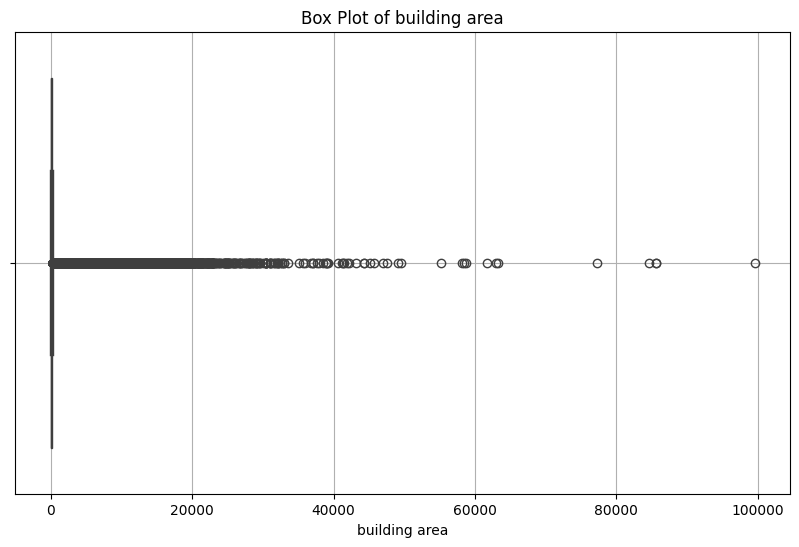

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
# df = pd.read_csv('your_dataset.csv')

# Specify the column you want to analyze
column_name = 'building area'

# Calculate summary statistics
summary_stats = df[column_name].describe()
print("Summary Statistics:")
print(summary_stats)

# Plot box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df[column_name])
plt.title(f'Box Plot of {column_name}')
plt.xlabel(column_name)
plt.grid(True)
plt.show()

In [11]:
# export the results to a csv file
df.to_csv('results_regression_20241025.csv', index=False)


In [12]:
# check null values
df.isnull().sum().to_csv('null_values_after_regression_20241026.csv')


## **Read and Compare null values**

C:\Users\xiongs\AppData\Local\Temp\ipykernel_2188\2799239733.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  null_values_regression['Data Enrichment Score'] = null_values_regression['Percentage Before'] - null_values_regression['Percentage After']


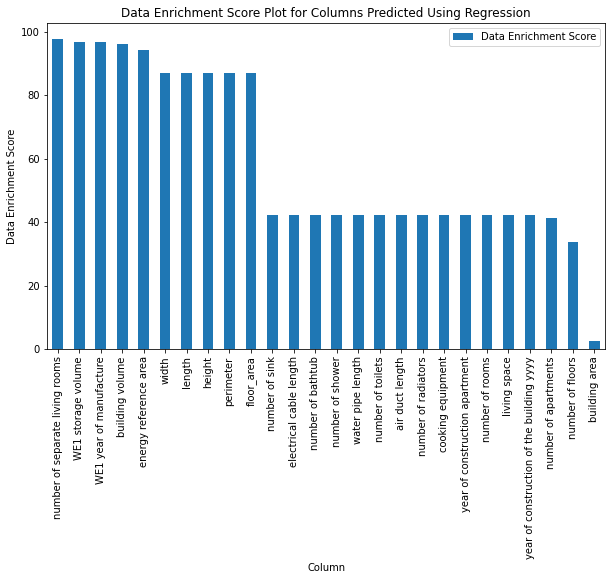

<Figure size 1800x1200 with 0 Axes>

In [14]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Load the null value files
# null_values_before = pd.read_csv('null_values_before_predictors_20231112.csv')
# null_values_after = pd.read_csv('null_values_filled_after_regression_20231112.csv')

# # Merge the two dataframes on the column 'Unnamed: 0'
# null_values = pd.merge(null_values_before, null_values_after, on='Unnamed: 0')

# # Rename the columns
# null_values.columns = ['Column', 'Null Values Before', 'Null Values After']

# # Calculate the percentage of null values before and after enrichment
# null_values['Percentage Before'] = null_values['Null Values Before'] / len(df) * 100
# null_values['Percentage After'] = null_values['Null Values After'] / len(df) * 100

# # Get the columns that were predicted using regression
# predictions_regression = ['year of construction of the building yyyy', 'building area',
#                           'height', 'length', 'width', 'perimeter','floor_area',
#                           'number of floors', 'number of apartments', 'number of separate living rooms',
#                           '9aNumber of residents (EFH/ MFH)',
#                           'living space', 'number of rooms', 'cooking equipment', 'number of radiators',
#                           'air duct length', 'water pipe length', 'number of toilets',
#                           'number of sink', 'number of shower', 'number of bathtub',       
#                           'electrical cable length',
#                          'energy reference area', 'building volume',
#                          'year of construction apartment', 
#                          '1hYear of construction', '2hInst./Renov. hot water supply','2iInst./Renov. heating system','5Area-related outside air volume flow V/AE',
#                          '7Year of manufacture', '8bPrevious heating consumption kWh/a',
#                          '9aEBF Total (m2)', '9dNumber of apartments','WE1 year of manufacture', 'WE1 storage volume' ] 

# # Filter the null_values dataframe to only include the columns that were predicted using regression
# null_values_regression = null_values[null_values['Column'].isin(predictions_regression)]

# # Calculate the data enrichment score for each column
# null_values_regression['Data Enrichment Score'] = null_values_regression['Percentage Before'] - null_values_regression['Percentage After']

# # Sort the dataframe by data enrichment score
# null_values_regression = null_values_regression.sort_values(by='Data Enrichment Score', ascending=False)

# # Plot the data enrichment score for each column
# null_values_regression.plot(x='Column', y='Data Enrichment Score', kind='bar', figsize=(10,6))

# # Set the title and axis labels
# plt.title('Data Enrichment Score Plot for Columns Predicted Using Regression')
# plt.xlabel('Column')
# plt.ylabel('Data Enrichment Score')
# # Set the figure resolution to 300dpi
# plt.figure(dpi=300)
# plt.show()

## **Predict with CNN**

In [59]:
df['energy/heat source heating 1'].unique() # 20

array(['fuel oil', 'wood (generic)', 'gas', 'indefinite', 'electricity',
       'district heating (generic)', nan, 'geothermal (generic)', 'Air',
       'sun (thermal)', 'No', 'Other', 'wood', 'geothermal probe',
       'earth register', 'wood (pellets)', 'wood (chips)',
       'Water (groundwater, surface water, waste water)',
       'District heating (low temperature)',
       'District heating (high temperature)',
       'Waste heat (inside the building)'], dtype=object)

In [2]:
conda install torchvision

Solving environment: ...working... failed with initial frozen solve. Retrying with flexible solve.
Solving environment: ...working... failed with repodata from current_repodata.json, will retry with next repodata source.
Solving environment: ...working... done

## Package Plan ##

  environment location: c:\ProgramData\Anaconda3

  added / updated specs:
    - torchvision


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    boltons-23.0.0             |   py39haa95532_0         421 KB
    conda-23.3.1               |   py39haa95532_0         972 KB
    jsonpatch-1.33             |   py39haa95532_1          57 KB
    jsonpointer-2.1            |     pyhd3eb1b0_0           9 KB
    libuv-1.44.2               |       h2bbff1b_0         288 KB
    ninja-1.10.2               |       haa95532_5          14 KB
    ninja-base-1.10.2          |       h6d14046_5         255 KB
    pytorch-1.12.1      


EnvironmentNotWritableError: The current user does not have write permissions to the target environment.
  environment location: c:\ProgramData\Anaconda3




In [5]:
import numpy as np
import pandas as pd
from io import StringIO
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import torch
from torch.utils.data import Dataset, DataLoader
import torch.utils.data as data
# from torchvision import datasets
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
# from torchvision import transforms
# from torchvision.transforms import ToTensor
from sklearn.metrics import accuracy_score
import torch.optim as optim
import matplotlib.pyplot as plt
import tqdm
from sklearn import svm

import warnings
warnings.filterwarnings("ignore")
import matplotlib.gridspec as gridspec
# from IPython import display
# display.set_matplotlib_formats("svg")

# Define the neural network architecture

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [6]:
device

device(type='cpu')

In [99]:
import numpy as np
import pandas as pd
from io import StringIO
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import torch
from torch.utils.data import Dataset, DataLoader
import torch.utils.data as data
from torchvision import datasets
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torchvision.transforms import ToTensor
from sklearn.metrics import accuracy_score
import torch.optim as optim
import matplotlib.pyplot as plt
import tqdm
from sklearn import svm

import warnings
warnings.filterwarnings("ignore")
import matplotlib.gridspec as gridspec
# from IPython import display
# display.set_matplotlib_formats("svg")

# Define the neural network architecture

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 512)
        self.bn3 = nn.BatchNorm1d(512)
        self.fc4 = nn.Linear(512, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.fc5 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)
        self.fc6 = nn.Linear(128, 64)
        self.bn6 = nn.BatchNorm1d(64)
        self.fc7 = nn.Linear(64, 32)
        self.bn7 = nn.BatchNorm1d(32)
        self.fc8 = nn.Linear(32, n_output)

        # Initialize weights using He initialization
        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in', nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in', nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc3.weight, mode='fan_in', nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc4.weight, mode='fan_in', nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc5.weight, mode='fan_in', nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc6.weight, mode='fan_in', nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc7.weight, mode='fan_in', nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc8.weight, mode='fan_in', nonlinearity='relu')

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = F.relu(self.bn4(self.fc4(x)))
        x = F.relu(self.bn5(self.fc5(x)))
        x = F.relu(self.bn6(self.fc6(x)))
        x = F.relu(self.bn7(self.fc7(x)))
        x = F.dropout(x, p=0.6, training=self.training)  # dropout regularization
        x = self.fc8(x)
        return x


# clf = svm.SVC(gamma=0.001, C=100.)

# Parameter settings
batch_size = 12800
num_epochs = 100

# Create a LabelEncoder for each column with string values
label_encoders = {}
for col in df.columns:
    # print(col)
    if df[col].dtype == 'object':
        label_encoders[col] = LabelEncoder()
        df[col] = label_encoders[col].fit_transform(df[col].fillna('').astype(str))

# Columns that are categorical and suitable for classification methods
predictions_classification = ['energy/heat source heating 1',
                            'energy/heat source heating 2', 
                            'energy/heat source hot water 1',
                            'energy/heat source hot water 2', 
                            '[6a]Building category',
                            'building category', 'building class', 'building status',
                            'heat generator heating 1', 'heat generator heating 2',
                            'heat generator hot water 1', 'heat generator hot water 2',
                            'WE1 Powered distribution systems',  'WE1 storage'
                              ]

# # get the most correlated columns for predictor
# df_predictor = pd.DataFrame()
# for col in df.columns:

#  # Calculate the correlation coefficients between all columns and the target variable
#  correlations = df.corr()[col].abs()
#  # Sort the correlations in descending order
#  sorted_correlations = correlations.sort_values(ascending=False)

#  # Select the top N correlated columns as predictors (excluding the target column itself)
#  N = 3
#  predictors = sorted_correlations.index[1:N+1]
#  # Append a new column to the dataframe with the predictors and the target variable
#  df_predictor[col] = list(predictors)

# import the dataframe with the predictors
df_predictor = pd.read_csv('df_predictor.txt')

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

for idx, item in enumerate(predictions_classification):
    # get the aggregated list of the top N correlated columns for each column
    predictors = list(df_predictor[item].values)

    X = torch.tensor(df[predictors].values, dtype=torch.float)

    aa = X.shape

    y = torch.tensor(df[item].values,dtype=torch.long)
    # get number of unique values in the target column

    bb = y.shape

    n_output = df[item].nunique()
    n_output = n_output + 10

    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Define the PyTorch dataset for the training set
    train_data = TensorDataset(X_train, y_train)

    # Define the PyTorch dataset for the testing set
    test_data = TensorDataset(X_test, y_test)

    # Define the PyTorch dataloader for the training set
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

    # Define the PyTorch dataloader for the testing set
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    # Instantiate the neural network
    net = Net()

    # Put net on the GPU
    net.to(device)

    # Define the loss function
    loss_fn = nn.CrossEntropyLoss()

    # Define the optimizer
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, verbose=True)
    # Train the neural network
    train_loss = []
    train_acc = []
    test_loss = []
    test_acc = []

    for epoch in tqdm.tqdm(range(num_epochs)):
        epoch_loss = 0.0
        epoch_correct = 0

        net.train()
        
        # Train the neural network on the training set
        for inputs, labels in train_loader:

            # Put data on the device
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = net(inputs)
            loss = loss_fn(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            epoch_correct += (predicted == labels).sum().item()

        train_loss.append(epoch_loss / len(train_loader))
        train_acc.append(epoch_correct / len(train_loader.dataset))
        
        # Evaluate the neural network on the testing set
        with torch.no_grad():
            epoch_loss = 0.0
            epoch_correct = 0
            
            for inputs, labels in test_loader:
                
                # Put data on the device
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = net(inputs)
                loss = loss_fn(outputs, labels)
                
                epoch_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                epoch_correct += (predicted == labels).sum().item()
            
            test_loss.append(epoch_loss / len(test_loader))
            test_acc.append(epoch_correct / len(test_loader.dataset))
        
        print("Target [{}], Epoch [{}/{}], Train Loss: {:.4f}, Test Loss: {:.4f}, Train Acc: {:.4f}, \
                Test Acc: {:.4f}".format(idx, epoch+1, num_epochs, train_loss[-1], test_loss[-1], train_acc[-1], test_acc[-1]))

    # Evaluate the model on the test
    net.eval()

    # Todo: Seems not needed?
    # #Collect the model's predictions and true labels
    # y_pred = []
    # y_true = []
    # with torch.no_grad():
    #     for inputs, labels in test_loader:

    #         # Put data on the device
    #         inputs, labels = inputs.to(device), labels.to(device)

    #         outputs = net(inputs)
    #         _, predicted = torch.max(outputs.data, 1)
    #         y_pred.extend(predicted.tolist())
    #         y_true.extend(labels.tolist())

    # # Compute the test set accuracy and print it
    # test_acc_final = accuracy_score(y_true, y_pred)
    # print("Test set accuracy: {:.4f}".format(test_acc_final))

    # Save the trained model
    torch.save(net.state_dict(), 'trained_model_{}.pth'.format(item.replace(' ', '_').replace('/', '_')))

    # Plot the training and testing losses
    plt.figure()
    plt.plot(train_acc, label='Train Acc')
    plt.plot(test_acc, label='Test Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    # add title
    plt.title('Accuracy Curve - ' + item)
    plt.legend()
    # save figure
    
    plt.savefig('accuracy_curve_{}.png'.format(item.replace(' ', '_').replace('/', '_')))

    # Close the figure
    plt.close()

# Inverse transform the encoded values back to their original form
for col in label_encoders:
    df[col] = label_encoders[col].inverse_transform(df[col])

# Save the filled DataFrame as a CSV file
df.to_csv('data_filled_cnn_20231112.txt', index=False)


ModuleNotFoundError: No module named 'torchvision'